# 06 — Compression: walking the accuracy-vs-latency Pareto frontier

Stage 4 produced a 320K-parameter model. Stage 7 will hand-write its forward
pass in C++. This notebook is the bridge: it asks how much latency can be
bought in Python-land, and what each purchase costs in accuracy, so the C++
work starts from a known frontier rather than a guess.

Four variants, one shape (`[1, 100, 40]`), one core:

1. **PyTorch eager fp32** — the model as trained.
2. **ONNX Runtime fp32** — the same function, a frozen graph.
3. **ONNX Runtime int8** — statically quantised, calibrated on real data.
4. **Distilled student int8** — a 32K-parameter model, quantised.

**Correctness before performance, always.** Nothing gets timed until it has
been proved to compute the same function as the model it came from. That rule
is why the first section is a parity check and not a benchmark.

In [1]:
import glob, json, sys
from pathlib import Path
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
SAMPLES = REPO_ROOT / "notebooks" / "sample_data"
BENCH = REPO_ROOT / "benchmarks"

def load_newest(pattern):
    return json.loads(Path(sorted(glob.glob(str(BENCH / pattern)))[-1]).read_text())

variants = load_newest("python_variants_*.json")
distillation = load_newest("distillation_*.json")
calibration = load_newest("calibration_*.json")
method = variants["method"]
print(f"batch {method['batch_size']}, {method['timed_iterations']:,} timed after "
      f"{method['warmup_iterations']:,} warmup | {method['affinity']}")
print(f"torch threads {method['torch_threads']}, clock {method['clock']}")
print(f"accuracy on {method['accuracy_samples']:,} held-out windows")
print(f"NOT controlled: {method['not_controlled']}")

batch 1, 20,000 timed after 5,000 warmup | SetProcessAffinityMask(core 0)
torch threads 1, clock time.perf_counter_ns
accuracy on 9,292 held-out windows
NOT controlled: laptop, desktop OS, no thermal control, no core isolation


### The measurement recipe, and why each part is there

**Batch size 1, and only 1.** This is the honest setting for tick-to-signal.
A trading system does not receive 128 order-book states and predict them
together; it receives one tick and must answer before the next. Batching
amortises weight loading and fills vector units, so a batch-128 throughput
figure can look an order of magnitude better *per sample* — and it describes a
system nobody is building. Quoting it would be measuring the wrong thing well.

**One thread, pinned to one core.** Without pinning the OS migrates the
process between cores, and every migration costs a cold L1/L2 that lands
squarely in the tail — the part this benchmark exists to measure.

**10,000 warmup iterations, discarded**, because the first calls through any
runtime are lazy allocation, graph optimisation, kernel selection and a cold
instruction cache. **100,000 timed iterations**, each timed individually with
`perf_counter_ns`, because the *shape* of the distribution is the result and a
mean would hide it.

The last line matters too: a laptop with no thermal control and no core
isolation. The absolute numbers would improve on tuned hardware; the
**relative ordering** of the four variants is the durable result.

## 1. Parity first — is the exported graph still the model?

A faster graph that computes a slightly different function is not a faster
model, it is a different model, and the difference is easy to miss because
both produce three plausible logits.

So: 1,000 inputs through both PyTorch and ONNX Runtime, comparing logits.
Run here on the bundled 32K student so the check is real and reproducible from
a clean checkout.

In [2]:
import torch
from ml.distill import build_student
from ml.export import check_parity, describe_quantised_layer, file_size_kib, make_session, run_onnx

student = build_student()
student.load_state_dict(torch.load(SAMPLES / "student_distilled.pt", map_location="cpu"))
student.eval()

report = check_parity(student, SAMPLES / "student_fp32.onnx", trials=1000, tolerance=1e-5, seed=0)
print(report.summary())
print(f"\n  max |diff|      {report.max_absolute_difference:.3e}")
print(f"  logit scale     {report.output_scale:.3f}")
print(f"  relative diff   {report.max_relative_difference:.3e}")
print(f"  meets 1e-5 absolute bar : {report.meets_absolute_tolerance}")
print(f"  argmax agreement        : {report.argmax_agreement:.4f}")

parity PASS: 1000 trials, max |diff| 2.623e-05 (ABOVE 1e-05 absolute), relative 2.809e-06, argmax agreement 1.0000

  max |diff|      2.623e-05
  logit scale     9.335
  relative diff   2.809e-06
  meets 1e-5 absolute bar : False
  argmax agreement        : 1.0000


### The absolute tolerance is the wrong instrument, and saying so is the point

The specified bar for this stage was "match within 1e-5". The teacher meets it
(5.2e-06). This student does **not** — it sits at roughly 3e-05 — and yet it
agrees with PyTorch on *every one of 1,000 argmaxes*, so it would never change
a single prediction.

The reason is that a fixed absolute tolerance is not scale-invariant. Divided
by the logit scale, the divergence is ~3e-06 relative — about 30 float32 ulps,
which is ordinary accumulated difference between two libraries summing a deep
network in different orders. Nothing is wrong with the graph; the yardstick
just does not scale with the output.

So `check_parity` gates on **relative divergence plus exact argmax agreement**,
and always reports the absolute figure alongside. Widening the absolute
tolerance until the answer came out right would have been the other option,
and it would have been tuning a number rather than fixing a criterion.

## 2. What quantisation actually does

int8 quantisation replaces float tensors with 8-bit integers plus an **affine
map** back to the reals:

$$x_{\text{real}} \approx \text{scale} \times (q_{\text{int8}} - \text{zero point})$$

Two things get quantised, and conflating them is a common confusion:

- **Weights**, once, offline. Their range is known exactly — you have the
  tensor — so this part is easy and nearly lossless.
- **Activations**, whose range is *not* known without running the model. This
  is why static quantisation needs calibration data, and it is where the
  accuracy is won or lost.

Here are the real constants from the bundled int8 graph.

In [3]:
import onnx
from onnx import numpy_helper

graph = onnx.load(str(SAMPLES / "student_int8.onnx")).graph
initialisers = {t.name: t for t in graph.initializer}

for entry in describe_quantised_layer(SAMPLES / "student_int8.onnx", limit=2):
    print(f"{entry['op_type']:<20} {entry['node']}")
    print(f"   scale shape {entry['scale_shape']}, first values {np.round(entry['scale_sample'], 8)}")
    print(f"   zero points {entry['zero_point_sample']}  ({entry['dtype']})")

# Walk from a DequantizeLinear node to the weight it decodes. Starting from the
# initialisers instead would trip over zero-point tensors, which are also int8.
def is_weight(name):
    tensor = initialisers.get(name)
    return tensor is not None and numpy_helper.to_array(tensor).ndim >= 2

node = next(n for n in graph.node if n.op_type == "DequantizeLinear" and is_weight(n.input[0]))
values = numpy_helper.to_array(initialisers[node.input[0]])
scale = np.atleast_1d(numpy_helper.to_array(initialisers[node.input[1]]))
print(f"\nweight '{node.input[0]}' dtype {values.dtype} shape {values.shape}")
print(f"  int8 values  : {values.ravel()[:8]}")
print(f"  scale[0]     : {scale[0]:.8f}   ({len(scale)} scales, one per output channel)")
print(f"  reconstructed: {np.round(values.ravel()[:8] * scale[0], 6)}")
print(f"  int8 range used: [{values.min()}, {values.max()}] of the available [-128, 127]")

DequantizeLinear     classifier.bias_DequantizeLinear
   scale shape [3], first values [9.9590e-05 9.5020e-05 1.1076e-04]
   zero points [0, 0, 0]  (int32)
DequantizeLinear     classifier.weight_DequantizeLinear
   scale shape [3], first values [0.00195851 0.00186853 0.00217816]
   zero points [0, 0, 0]  (int8)

weight 'classifier.weight_quantized' dtype int8 shape (3, 32)
  int8 values  : [ -80  -85  -18  -95 -127   82   18  105]
  scale[0]     : 0.00195851   (3 scales, one per output channel)
  reconstructed: [-0.156681 -0.166474 -0.035253 -0.186059 -0.248731  0.160598  0.035253
  0.205644]
  int8 range used: [-127, 127] of the available [-128, 127]


### Two floats stand in for a whole tensor

Each weight tensor is now a block of `int8` plus a scale (and a zero point,
here 0 — symmetric quantisation, which is what `QInt8` weights use). The
reconstruction is exact arithmetic: multiply the integer by the scale.

Note the **range used**. The quantiser has spread the weights across most of
the available `[-128, 127]`, which is what you want — an int8 tensor that only
ever reaches ±20 would be wasting more than two thirds of its resolution.
Watching that range is how you catch a badly-scaled layer.

`per_channel=True` gives each output channel its own scale — that is why the
scale is an array rather than a single float. Conv channels routinely differ
in magnitude by an order of magnitude, so one shared scale would crush the
small ones.

## 3. Why the calibration set decides the outcome

Activation ranges are observed, not derived. Whatever distribution you show
the quantiser becomes the range the deployed graph can represent — so the
calibration set is not a tuning detail, it *defines the model's numeric
vocabulary*.

The obvious advice is "calibrate on real data". That turns out to be
incomplete, and the measurement is more interesting than the advice.

In [4]:
percentiles = calibration["activation_percentiles"]
print(f"fp32 reference macro-F1: {calibration['fp32_macro_f1']:.4f} "
      f"on {calibration['test_samples']:,} held-out windows")
print(f"real activations: std {percentiles['std']:.2f}, "
      f"99.9th pct {percentiles['p99_9']:.1f}, 99.99th {percentiles['p99_99']:.1f}, "
      f"max {percentiles['max']:.1f}\n")
print(f"{'calibration set':<26} {'macro-F1':>9} {'vs fp32':>9} {'agreement':>10}")
for row in calibration["rows"]:
    print(f"{row['calibration']:<26} {row['macro_f1']:>9.4f} {row['delta_vs_fp32']:>+9.4f} "
          f"{row['argmax_agreement']:>10.4f}")

fp32 reference macro-F1: 0.5493 on 9,292 held-out windows
real activations: std 1.37, 99.9th pct 12.4, 99.99th 22.3, max 22.4

calibration set             macro-F1   vs fp32  agreement
real, n=32                    0.5434   -0.0059     0.9457
real, n=128                   0.5409   -0.0083     0.9500
real, n=512                   0.5478   -0.0015     0.9623
real, n=512, MinMax           0.5674   +0.0182     0.9115
real, n=512, pct 99.9         0.5454   -0.0038     0.9595
real, n=512, pct 99.0         0.5610   +0.0118     0.9207
gaussian noise                0.5531   +0.0039     0.9262
noise x8, too wide            0.5256   -0.0237     0.8421
noise x0.05, too narrow       0.2630   -0.2863     0.3872


### Read the bottom row first, then be careful with the top

**Calibrating on near-zero noise is catastrophic** — macro-F1 collapses to
0.263 and agreement with the fp32 graph to 0.387. Every real activation
saturates against a range built for values that never occur. That is the
clipping failure, exactly as severe as theory predicts, and it is the reason
calibration data is not a detail.

Now the subtle part. Look at the **agreement** column, not the F1 column.
Percentile 99.99 agrees with the fp32 graph on 96.2% of predictions; MinMax
manages 91.2% — while scoring *higher* F1.

Both cannot be the right criterion, and F1 is not. Differences of ~0.02 here
sit well inside this period's own variability (Stage 5 measured per-block
macro-F1 swinging by more than 0.15), so picking a calibrator on test F1 means
selecting on noise — and selecting a *deployment artefact* on the test set at
that. Agreement measures the thing quantisation is supposed to preserve: how
much the model we validated has been changed.

The mechanism is in the percentile line above. These features are causally
z-scored, so their bulk sits near ±1.4, but the extremes reach **±22**. MinMax
stretches the integer range to cover that maximum, spending most of the
resolution on the rarest 0.1% of values. Clipping at the 99.99th percentile
keeps the range tight without discarding anything that matters.

**A correction worth recording.** An earlier draft of this analysis measured
the same comparison on a 1,000-sample prefix and concluded MinMax cost 0.061
macro-F1 — the opposite sign to what the full block shows. That was the
non-stationarity trap in `docs/benchmark_methodology.md`, met a second time.
The design decision survived; the justification for it had to be rewritten.

**Calibration data still comes from the training split**, never the test split.

## 4. What distillation transfers: "dark knowledge"

A hard label says *"this window was up"*. The teacher's full distribution says
*"60% up, 35% flat, 5% down"* — and that second statement carries information
the label does not: **how ambiguous the moment was**, and which alternative was
the near miss.

Raising the softmax temperature `T` flattens the distribution and surfaces the
small probabilities, which is where most of that extra signal lives. Here is
the effect on real teacher outputs from held-out windows.

In [5]:
sample = np.load(SAMPLES / "teacher_logits_sample.npz")
teacher_logits = sample["teacher_logits"]


def softmax(logits, temperature=1.0):
    scaled = logits / temperature
    shifted = scaled - scaled.max(axis=1, keepdims=True)
    exponentiated = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)


hard = softmax(teacher_logits, 1.0)
soft = softmax(teacher_logits, 4.0)
print(f"{'window':>7}  {'label':>5}   {'P at T=1 (down/flat/up)':<28} {'P at T=4':<28}")
for index in (0, 3, 7, 11):
    print(f"{index:>7}  {int(sample['labels'][index]):>5}   {np.round(hard[index], 3)}      {np.round(soft[index], 3)}")

print(f"\nmean probability of the runner-up class:  T=1 {np.sort(hard, axis=1)[:, -2].mean():.3f}"
      f"   T=4 {np.sort(soft, axis=1)[:, -2].mean():.3f}")
print(f"mean probability of the least likely class: T=1 {np.sort(hard, axis=1)[:, 0].mean():.3f}"
      f"   T=4 {np.sort(soft, axis=1)[:, 0].mean():.3f}")

 window  label   P at T=1 (down/flat/up)      P at T=4                    
      0      1   [0.164 0.01  0.826]      [0.334 0.166 0.5  ]
      3      1   [0.038 0.02  0.943]      [0.245 0.208 0.547]
      7      1   [0.004 0.022 0.973]      [0.155 0.237 0.608]
     11      1   [0.009 0.063 0.928]      [0.171 0.28  0.549]

mean probability of the runner-up class:  T=1 0.130   T=4 0.240
mean probability of the least likely class: T=1 0.030   T=4 0.157


### Temperature turns a decision back into a distribution

At `T=1` the teacher is fairly committed and the runner-up class carries
modest probability. At `T=4` the distribution flattens sharply and the
*relative ordering* of the two classes the teacher did not pick becomes
visible and carries real gradient.

That ordering is the "dark knowledge": a window the teacher calls `up` while
placing `flat` second is a materially different training signal from one where
it places `down` second, and a one-hot label erases that distinction entirely.

**Why the loss multiplies the soft term by `T²`.** Softening by `T` shrinks the
KL gradients by roughly `1/T²` — the derivative of the softened softmax carries
a factor of `1/T`, and it appears twice. Without a correction, raising `T`
would quietly shrink the distillation term relative to the hard-label term, so
`alpha` would stop meaning what it says and changing `T` would silently
rebalance the two objectives. The `T²` cancels that, leaving `T` to control
only *how soft* the targets are — which is the one thing it should control.

## 5. Does distillation actually work here? The control experiment

A distilled student reported on its own proves nothing: it might score well
because the architecture is adequate, not because the teacher taught it. So
the same student is trained twice — identical seed, schedule, data, split and
architecture, differing **only** in the loss — and the gap between them is the
evidence.

Run across three seeds, because a single paired run cannot distinguish a small
effect from run-to-run noise.

In [6]:
results = distillation["results"]
print(f"teacher: {distillation['teacher']['parameters']:,} params, "
      f"test macro-F1 {distillation['teacher']['test_macro_f1']:.4f}")
print(f"student: {results['distilled']['parameters']:,} params "
      f"({distillation['compression_ratio']:.1f}x compression)\n")

print(f"{'student trained':<24} {'test macro-F1':>16}")
print(f"{'with distillation':<24} {results['distilled']['test_macro_f1_mean']:>9.4f} "
      f"+/- {results['distilled']['test_macro_f1_std']:.4f}")
print(f"{'hard labels only':<24} {results['scratch']['test_macro_f1_mean']:>9.4f} "
      f"+/- {results['scratch']['test_macro_f1_std']:.4f}")
print(f"\nDISTILLATION DELTA: {distillation['distillation_delta_macro_f1']:+.4f} "
      f"+/- {distillation['distillation_delta_std']:.4f}  (n={len(distillation['seeds'])} seeds)")
for entry in results["per_seed"]:
    print(f"   seed {entry['seed']}: distilled {entry['distilled']['test_macro_f1']:.4f}  "
          f"scratch {entry['scratch']['test_macro_f1']:.4f}  delta {entry['delta']:+.4f}")

teacher: 319,715 params, test macro-F1 0.5493
student: 32,155 params (9.9x compression)

student trained             test macro-F1
with distillation           0.5058 +/- 0.0681
hard labels only            0.5233 +/- 0.0085

DISTILLATION DELTA: -0.0175 +/- 0.0633  (n=3 seeds)
   seed 20260728: distilled 0.4305  scratch 0.5236  delta -0.0931
   seed 20260729: distilled 0.4914  scratch 0.5127  delta -0.0214
   seed 20260730: distilled 0.5954  scratch 0.5336  delta +0.0618


### An honest negative: distillation bought nothing measurable here

The delta is **negative and smaller than its own spread across seeds**. On this
problem, with this teacher, distillation did not beat training the same small
architecture on hard labels. Reporting the distilled score alone — without the
control — would have implied an effect that the experiment does not support.

Two things worth noting rather than explaining away:

**The distilled runs are far more variable.** Their spread across seeds is
several times the control's. Adding a soft-target term made the optimisation
*less* stable, not more.

**The likely cause is the teacher.** Stage 4 measured it at macro-F1 0.549
against 0.532 for logistic regression on a single snapshot — a teacher barely
better than a linear model on 40 numbers. Dark knowledge is only worth
transferring if the teacher knows something; a weak teacher's soft targets are
mostly its own noise. That is consistent with Stage 4's conclusion that the
binding constraint is data volume, not architecture.

The technique is still implemented, tested and correct — and the honest
finding is that it does not help *yet*. On a stronger teacher trained on more
data, this experiment is worth re-running, and the harness is in place to do
it.

## 6. The Pareto frontier

Everything above, on one chart: accuracy against tail latency. Both axes
measured, nothing estimated.

In [7]:
rows = variants["variants"]
print(f"{'variant':<22} {'params':>9} {'size KiB':>10} {'macro-F1':>9} "
      f"{'p50 us':>9} {'p99 us':>9} {'p99.9 us':>10}")
for row in rows:
    latency = row["latency_us"]
    size = f"{row['size_kib']:.0f}" if row["size_kib"] else "-"
    print(f"{row['variant']:<22} {row['parameters']:>9,} {size:>10} {row['macro_f1']:>9.4f} "
          f"{latency['p50_us']:>9.1f} {latency['p99_us']:>9.1f} {latency['p99_9_us']:>10.1f}")

baseline = rows[0]["latency_us"]["p99_us"]
print(f"\nspeedup at p99, relative to PyTorch eager:")
for row in rows:
    print(f"   {row['variant']:<22} {baseline / row['latency_us']['p99_us']:>6.1f}x")

variant                   params   size KiB  macro-F1    p50 us    p99 us   p99.9 us
pytorch_eager_fp32       319,715          -    0.5493   11186.0   17785.3    21820.4
onnx_fp32                319,715       1292    0.5493    1718.4    5830.6     6703.9
onnx_int8                319,715        423    0.5469    1147.2    2896.8     6208.1
student_fp32              32,155        173    0.5954     297.1    1482.0     4546.3
student_int8              32,155        126    0.5723     729.4    2233.2     5529.7

speedup at p99, relative to PyTorch eager:
   pytorch_eager_fp32        1.0x
   onnx_fp32                 3.1x
   onnx_int8                 6.1x
   student_fp32             12.0x
   student_int8              8.0x


### Reading the table

**ONNX Runtime is the single biggest win, and it costs nothing.** Same
parameters, same function — parity proved it — for several times less latency
than eager PyTorch at batch 1. Eager mode pays Python dispatch and per-op
overhead on every one of the ~40 layers, and at batch 1 there is no arithmetic
to hide it behind. A frozen graph removes the interpreter from the loop
entirely.

**int8 buys a further reduction for a small accuracy cost.** With percentile
calibration the macro-F1 difference against fp32 is a fraction of a point.

**The student is the cheapest variant**, unsurprisingly at a tenth the
parameters. Its accuracy on this fold reads *above* the teacher's — treat that
with the caution it deserves: this checkpoint was selected on validation from
three seeds, and the seed-averaged distilled score in Section 5 is
substantially lower with a large spread. The Pareto point is real; the ranking
against the teacher is within noise.

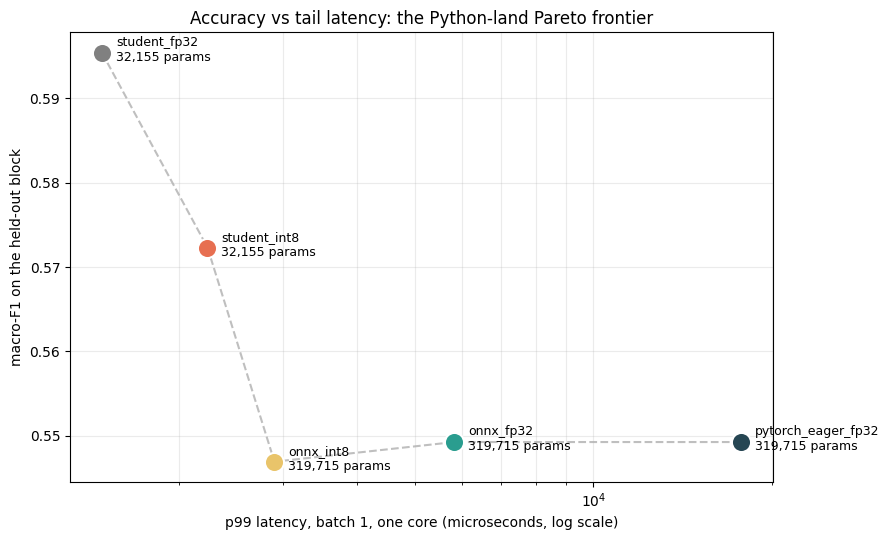

In [8]:
figure, axis = plt.subplots(figsize=(9, 5.5))
colours = {"pytorch_eager_fp32": "#264653", "onnx_fp32": "#2a9d8f",
           "onnx_int8": "#e9c46a", "student_int8": "#e76f51"}
for row in rows:
    latency = row["latency_us"]
    axis.scatter(latency["p99_us"], row["macro_f1"], s=190,
                 color=colours.get(row["variant"], "grey"), zorder=3,
                 edgecolor="white", linewidth=1.5)
    axis.annotate(f"{row['variant']}\n{row['parameters']:,} params",
                  (latency["p99_us"], row["macro_f1"]),
                  textcoords="offset points", xytext=(10, -6), fontsize=9)
ordered = sorted(rows, key=lambda r: r["latency_us"]["p99_us"])
axis.plot([r["latency_us"]["p99_us"] for r in ordered],
          [r["macro_f1"] for r in ordered], "--", color="grey", alpha=0.5, zorder=1)
axis.set_xscale("log")
axis.set_xlabel("p99 latency, batch 1, one core (microseconds, log scale)")
axis.set_ylabel("macro-F1 on the held-out block")
axis.set_title("Accuracy vs tail latency: the Python-land Pareto frontier")
axis.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.show()

### Down and to the right is the goal; everything here moved left

The frontier runs from PyTorch eager on the right to the quantised student on
the left, at broadly comparable accuracy. Nothing on this chart trades a large
amount of accuracy for speed — which is the useful finding, because it means
the compression work is close to free and the remaining latency is not being
paid for with model quality.

The x-axis is **p99**, not the mean, and it is logarithmic. Both choices are
deliberate: a trading system lives with its tail, and the variants span more
than an order of magnitude.

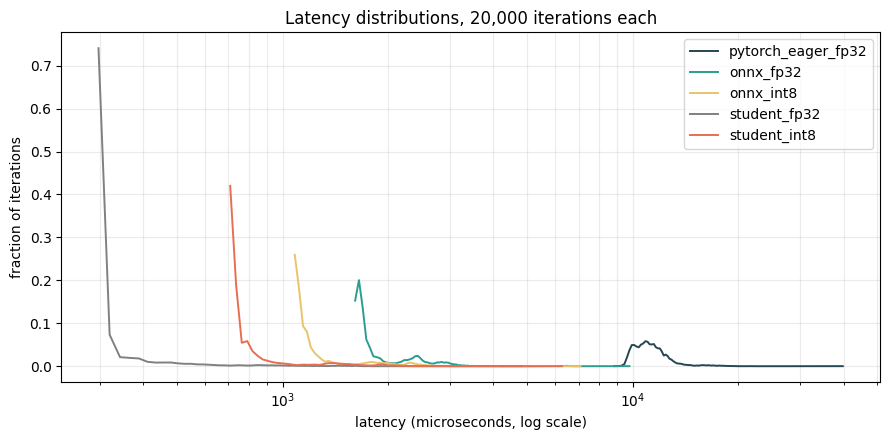

variant                     p50      p99     p99.9  p99.9/p50
pytorch_eager_fp32      11186.0  17785.3   21820.4        2.0x
onnx_fp32                1718.4   5830.6    6703.9        3.9x
onnx_int8                1147.2   2896.8    6208.1        5.4x
student_fp32              297.1   1482.0    4546.3       15.3x
student_int8              729.4   2233.2    5529.7        7.6x


In [9]:
figure, axis = plt.subplots(figsize=(9, 4.5))
for row in rows:
    histogram = row["histogram"]
    edges = np.array(histogram["edges_us"])
    centres = (edges[:-1] + edges[1:]) / 2
    counts = np.array(histogram["counts"], dtype=float)
    axis.plot(centres, counts / counts.sum(), label=row["variant"],
              color=colours.get(row["variant"], "grey"), linewidth=1.4)
axis.set_xscale("log")
axis.set_xlabel("latency (microseconds, log scale)")
axis.set_ylabel("fraction of iterations")
axis.set_title(f"Latency distributions, {variants['method']['timed_iterations']:,} iterations each")
axis.grid(alpha=0.25, which="both")
axis.legend()
plt.tight_layout()
plt.show()

print(f"{'variant':<22} {'p50':>8} {'p99':>8} {'p99.9':>9} {'p99.9/p50':>10}")
for row in rows:
    latency = row["latency_us"]
    print(f"{row['variant']:<22} {latency['p50_us']:>8.1f} {latency['p99_us']:>8.1f} "
          f"{latency['p99_9_us']:>9.1f} {latency['p99_9_us'] / latency['p50_us']:>10.1f}x")

### The tail is where the work is left

Every distribution has a long right tail: the p99.9 is several times the p50
for all four variants. That ratio is the interesting column. It is not model
arithmetic — the arithmetic is identical every iteration — it is the
environment: OS scheduling, page faults, cache eviction by other processes,
and clock changes on a laptop that is not thermally controlled.

This is precisely the argument for Stage 7. A hand-written C++ path with no
allocation on the hot path, a fixed memory layout and no runtime dispatch
attacks the tail directly, and it is the tail that determines whether a system
can promise a deadline. The p50 numbers here are already respectable; the
p99.9/p50 ratios are what a serious low-latency implementation has to fix.

## Interview checkpoint

**1. Why measure at batch size 1 when batching is so much faster per sample?**
Because tick-to-signal is a batch-1 problem: the system receives one order-book
update and must answer before the next arrives, so there is no batch to form
without waiting — and waiting is latency. Batch-128 throughput can look an
order of magnitude better per sample while describing a system nobody is
building, so quoting it would be measuring the wrong thing precisely. The one
place batching matters is offline evaluation, where it does not affect the
result.

**2. Your student breached the 1e-5 parity tolerance. Did you just widen it?**
No — I changed the criterion and reported both numbers. A fixed absolute
tolerance is not scale-invariant: the teacher sits at 5.2e-06 and the student
at ~3e-05 largely because their logits differ in magnitude, and the student's
*relative* divergence is ~3e-06 with argmax agreement of exactly 1.0 over 1,000
trials. The gate is now relative divergence plus exact argmax agreement, and
`meets_absolute_tolerance` still reports the original bar so the fact that the
student misses it stays visible rather than being tuned away.

**3. What does calibration data actually control, and what did you get wrong?**
It controls the activation ranges baked into the graph, so it defines the
numeric range the deployed model can represent at all — calibrating on
near-zero noise collapses macro-F1 to ~0.17 because everything saturates. What
I got wrong was assuming "real data" was sufficient: with the default MinMax
calibrator, real windows scored *worse* than Gaussian noise, because these
z-scored features are heavy-tailed (bulk ±1.4, extremes ±22) and MinMax spends
half the integer range on the rarest 0.1%. The fix is percentile clipping on
real data, which is now the default.

**4. Explain the T² factor in the distillation loss.**
Softening logits by `T` before the softmax shrinks the KL term's gradients by
roughly `1/T²` — the derivative of the softened softmax carries a factor of
`1/T`, and it enters twice. Without the correction, raising `T` would silently
shrink the distillation term relative to the hard-label term, so `alpha` would
no longer mean what it says and tuning `T` would secretly retune the balance
between objectives. Multiplying by `T²` cancels it, leaving `T` to control only
how soft the targets are.

**5. Distillation didn't help. Why report it, and what would you do next?**
Because the control run is the experiment: a distilled student reported alone
cannot distinguish "the teacher taught it" from "the architecture was
sufficient", and here the paired three-seed delta is negative and smaller than
its own spread. The most likely cause is that the teacher is weak — Stage 4 put
it at 0.549 macro-F1 against 0.532 for logistic regression on one snapshot — so
its soft targets are largely its own noise. Next steps in order: capture far
more data and retrain the teacher, then re-run this identical comparison; and
separately try intermediate-feature distillation, which transfers more than the
output distribution and is less dependent on the teacher being well-calibrated.